# EXPERIMENT 1
## Setting Up Python Environment and Libraries — Google Colab

**Dataset used throughout:** US Senate Financial Disclosures (Stocks & Options)

## Aim
To set up the Python/Colab notebook environment, understand the notebook interface, execute Python programs, create Markdown cells, and use basic libraries (NumPy, Pandas, Matplotlib) on a real dataset — the US Senate Financial Disclosures (Stocks & Options) dataset from Kaggle.

## Software Requirements
- Google Colab (Python 3, cloud-hosted, no local install needed)
- `kagglehub` (to fetch the dataset from Kaggle)
- `pandas`, `numpy`, `matplotlib`
- A Kaggle account (for the one-time authentication prompt)

## Theory
Python is a high-level, interpreted programming language widely used in Data Analytics, Machine Learning, Artificial Intelligence, Scientific Computing, and Data Visualization.

Google Colab is a free, cloud-hosted notebook environment (built on the same notebook document format as Jupyter Notebook) that lets users write and execute Python in the browser, with:
- Live Code
- Equations
- Visualizations
- Narrative Text

Colab supports Python out of the box, with GPU/TPU acceleration available, and integrates directly with Google Drive and GitHub for storage.

## Features of Google Colab
- Interactive computing in the browser — no installation required
- Real-time code execution on Google's cloud infrastructure
- Built-in data visualization support
- Markdown documentation cells
- Free access to GPUs/TPUs
- Easy sharing, exporting to `.ipynb`, PDF, and HTML

## Applications
- Data Analysis
- Machine Learning
- Deep Learning
- Statistical Analysis
- Scientific Research

## Algorithm

**Algorithm 1: Preparing the Colab Environment**
1. Open https://colab.research.google.com and create a New Notebook
2. Rename the notebook
3. Connect to a runtime (Runtime → Connect)
4. Install any extra libraries with `!pip install`
5. Verify the Python version

**Algorithm 2: Downloading the Dataset from Kaggle**
1. Install `kagglehub`
2. Call `kagglehub.dataset_download()` with the dataset slug
3. Authenticate with Kaggle when prompted (first run only)
4. List the downloaded files

**Algorithm 3: Creating and Running Cells**
1. Insert a Code cell and a Markdown cell
2. Write Python statements / Markdown text
3. Execute cells using Shift + Enter
4. Observe the output

## Program 1 — Simple Python Program

In [1]:
print("Welcome to Data Visualization Techniques Lab")

Welcome to Data Visualization Techniques Lab


**Expected Output:**
```
Welcome to Data Visualization Techniques Lab
```

## Program 2 — Arithmetic Operations

In [2]:
a = 20
b = 10

print("Addition =", a + b)
print("Subtraction =", a - b)
print("Multiplication =", a * b)
print("Division =", a / b)

Addition = 30
Subtraction = 10
Multiplication = 200
Division = 2.0


## Program 3 — Display Basic Variables

In [3]:
course = "Data Visualization Techniques"
dataset_name = "US Senate Financial Disclosures (Stocks & Options)"
source = "Kaggle"

print("Course:", course)
print("Dataset:", dataset_name)
print("Source:", source)

Course: Data Visualization Techniques
Dataset: US Senate Financial Disclosures (Stocks & Options)
Source: Kaggle


## Program 4 — Creating a Markdown Cell
Type the following text into a **Markdown** cell (not a code cell) and run it:

```markdown
# Data Visualization Techniques Lab
## Experiment 1
### Google Colab Environment
```

**Rendered Output:** a heading "Data Visualization Techniques Lab", sub-heading "Experiment 1", sub-sub-heading "Google Colab Environment".

## Environment Setup & Dataset Download

**Dataset:** [US Senate Financial Disclosures (Stocks & Options)](https://www.kaggle.com/datasets/lukekerbs/us-senate-financial-disclosures-stocks-and-options) — 2012-2024 stock and options trades disclosed by US Senators under the STOCK Act.

We use `kagglehub` to pull the dataset directly into the Colab runtime (no manual file upload needed).


In [4]:
# Install the Kaggle download helper
!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob, re

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (8, 5)

# Downloads "US Senate Financial Disclosures (Stocks & Options)" from Kaggle.
# NOTE: On the first run in a fresh Colab session, kagglehub may open a
# browser prompt asking you to sign in / authorize with your Kaggle account.
# (Even public datasets require a logged-in Kaggle identity.) Approve it
# once and it stays cached for the rest of the session. Alternatively,
# upload a kaggle.json API token to /root/.kaggle/ beforehand to skip the
# prompt entirely.
dataset_path = kagglehub.dataset_download("lukekerbs/us-senate-financial-disclosures-stocks-and-options")
print("Dataset files downloaded to:", dataset_path)
for f in os.listdir(dataset_path):
    print(" -", f)


100%|██████████| 71.4k/71.4k [00:00<00:00, 44.4MB/s]

Extracting files...
Dataset files downloaded to: /root/.cache/kagglehub/datasets/lukekerbs/us-senate-financial-disclosures-stocks-and-options/versions/1
 - senate_stock_discosures.csv


In [5]:
# Load the main transactions file (the largest CSV shipped with the dataset)
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))
main_csv = max(csv_files, key=os.path.getsize)
print("Loading:", main_csv)

df = pd.read_csv(main_csv, low_memory=False)
print("Raw shape:", df.shape)
df.head()


Loading: /root/.cache/kagglehub/datasets/lukekerbs/us-senate-financial-disclosures-stocks-and-options/versions/1/senate_stock_discosures.csv
Raw shape: (4699, 12)


,ticker,asset_name,asset_type,stock_price,transaction,transaction_date,asset_value_low,asset_value_high,last_name,first_name,owner,additional_details
0,RTX,RTX Corporation Common Stock,Stock,100.99,Sale (Full),04/09/2024,15001,50000,Whitehouse,Sheldon,Spouse,--
1,DHR,Danaher Corp,Stock,249.80,Sale (Full),04/09/2024,15001,50000,Whitehouse,Sheldon,Spouse,--
2,UL,Unilever Plc ADR,Stock,47.99,Sale (Full),04/09/2024,1001,15000,Whitehouse,Sheldon,Spouse,--
3,IR,Ingersoll Rand Inc,Stock,93.48,Sale (Full),04/09/2024,1001,15000,Whitehouse,Sheldon,Spouse,--
4,NVS,Novartis Ag ADR,Stock,95.81,Sale (Partial),04/09/2024,1001,15000,Whitehouse,Sheldon,Self,--


In [6]:
# ------------------------------------------------------------------
# Column resolver
# ------------------------------------------------------------------
# Different exports of this dataset have shipped with slightly different
# header names (e.g. "senator" vs "Senator", "ticker" vs "Symbol"). This
# helper scans the real column names and renames whichever column matches
# each concept we need onto a standard name, so the rest of the notebook
# reads cleanly (df["senator"], df["ticker"], ...) no matter the exact
# header text in the file we actually downloaded.

def resolve_columns(frame):
    search_order = [
        ("ticker",            ["ticker", "symbol"]),
        ("asset_type",        ["asset_type", "assettype"]),
        ("asset_description", ["asset_description", "asset_name", "security", "asset"]),
        ("type",              ["transaction_type", "type"]),
        ("owner",             ["owner"]),
        ("amount",            ["amount"]),
        ("transaction_date",  ["transaction_date", "trade_date"]),
        ("disclosure_date",   ["disclosure_date", "notification_date", "filed_date", "report_date"]),
        ("comment",           ["comment"]),
        ("party",             ["party"]),
        ("state",             ["state"]),
        ("senator",           ["senator", "member", "filer"]),
        ("first_name",        ["first_name", "firstname"]),
        ("last_name",         ["last_name", "lastname"]),
    ]
    available = {c.lower(): c for c in frame.columns}
    resolved = {}
    for concept, keys in search_order:
        found = None
        for key in keys:
            for lc in list(available.keys()):
                if key in lc:
                    found = available[lc]
                    break
            if found:
                break
        resolved[concept] = found
        if found:
            available.pop(found.lower(), None)
    return resolved

col_map = resolve_columns(df)
print("Detected column mapping:")
for concept, actual in col_map.items():
    print(f"  {concept:18s} -> {actual}")

# Build a 'senator' column out of first/last name if no single column exists
if col_map["senator"] is None and col_map["first_name"] and col_map["last_name"]:
    df["senator"] = df[col_map["first_name"]].astype(str) + " " + df[col_map["last_name"]].astype(str)
    col_map["senator"] = "senator"

# Standardise column names so the rest of the notebook can use simple,
# predictable names regardless of the file's original headers
rename_map = {v: k for k, v in col_map.items() if v is not None and v != k}
df.rename(columns=rename_map, inplace=True)

df.head()


Detected column mapping:
  ticker             -> ticker
  asset_type         -> asset_type
  asset_description  -> asset_name
  type               -> None
  owner              -> owner
  amount             -> None
  transaction_date   -> transaction_date
  disclosure_date    -> None
  comment            -> None
  party              -> None
  state              -> None
  senator            -> None
  first_name         -> first_name
  last_name          -> last_name


,ticker,asset_description,asset_type,stock_price,transaction,transaction_date,asset_value_low,asset_value_high,last_name,first_name,owner,additional_details,senator
0,RTX,RTX Corporation Common Stock,Stock,100.99,Sale (Full),04/09/2024,15001,50000,Whitehouse,Sheldon,Spouse,--,Sheldon Whitehouse
1,DHR,Danaher Corp,Stock,249.80,Sale (Full),04/09/2024,15001,50000,Whitehouse,Sheldon,Spouse,--,Sheldon Whitehouse
2,UL,Unilever Plc ADR,Stock,47.99,Sale (Full),04/09/2024,1001,15000,Whitehouse,Sheldon,Spouse,--,Sheldon Whitehouse
3,IR,Ingersoll Rand Inc,Stock,93.48,Sale (Full),04/09/2024,1001,15000,Whitehouse,Sheldon,Spouse,--,Sheldon Whitehouse
4,NVS,Novartis Ag ADR,Stock,95.81,Sale (Partial),04/09/2024,1001,15000,Whitehouse,Sheldon,Self,--,Sheldon Whitehouse


In [7]:
# ------------------------------------------------------------------
# Derive numeric / datetime helper columns
# ------------------------------------------------------------------
# "amount" is reported as a disclosure range, e.g. "$1,001 - $15,000".
# We parse it into numeric amount_min / amount_max / amount_mid columns.

def parse_amount_range(value):
    if pd.isna(value):
        return (np.nan, np.nan)
    nums = re.findall(r"[\d,]+", str(value))
    nums = [float(n.replace(",", "")) for n in nums if n.replace(",", "").isdigit()]
    if len(nums) == 0:
        return (np.nan, np.nan)
    if len(nums) == 1:
        return (nums[0], nums[0])
    return (min(nums), max(nums))

if "amount" in df.columns:
    ranges = df["amount"].apply(parse_amount_range)
    df["amount_min"] = ranges.apply(lambda t: t[0])
    df["amount_max"] = ranges.apply(lambda t: t[1])
    df["amount_mid"] = df[["amount_min", "amount_max"]].mean(axis=1)

for date_col in ["transaction_date", "disclosure_date"]:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

if "transaction_date" in df.columns and "disclosure_date" in df.columns:
    df["days_to_disclose"] = (df["disclosure_date"] - df["transaction_date"]).dt.days

if "transaction_date" in df.columns:
    df["transaction_year"] = df["transaction_date"].dt.year

print("Working shape:", df.shape)
df.head()


Working shape: (4699, 14)


,ticker,asset_description,asset_type,stock_price,transaction,transaction_date,asset_value_low,asset_value_high,last_name,first_name,owner,additional_details,senator,transaction_year
0,RTX,RTX Corporation Common Stock,Stock,100.99,Sale (Full),2024-04-09,15001,50000,Whitehouse,Sheldon,Spouse,--,Sheldon Whitehouse,2024
1,DHR,Danaher Corp,Stock,249.80,Sale (Full),2024-04-09,15001,50000,Whitehouse,Sheldon,Spouse,--,Sheldon Whitehouse,2024
2,UL,Unilever Plc ADR,Stock,47.99,Sale (Full),2024-04-09,1001,15000,Whitehouse,Sheldon,Spouse,--,Sheldon Whitehouse,2024
3,IR,Ingersoll Rand Inc,Stock,93.48,Sale (Full),2024-04-09,1001,15000,Whitehouse,Sheldon,Spouse,--,Sheldon Whitehouse,2024
4,NVS,Novartis Ag ADR,Stock,95.81,Sale (Partial),2024-04-09,1001,15000,Whitehouse,Sheldon,Self,--,Sheldon Whitehouse,2024


## Program 5 — Using the NumPy Library
Apply NumPy directly on a real column from the Senate dataset (the numeric mid-point of the disclosed transaction amount).

In [9]:
calculated_amount_mid = df[["asset_value_low", "asset_value_high"]].mean(axis=1)
amounts = calculated_amount_mid.dropna().to_numpy()

print("First 5 transaction amounts (USD, midpoint of range):")
print(amounts[:5])
print("Mean amount   =", np.mean(amounts))
print("Max amount    =", np.max(amounts))
print("Total trades with a valid amount =", np.sum(~np.isnan(calculated_amount_mid)))

First 5 transaction amounts (USD, midpoint of range):
[32500.5 32500.5  8000.5  8000.5  8000.5]
Mean amount   = 33044.01989785061
Max amount    = 37500000.5
Total trades with a valid amount = 4699


## Program 6 — Using the Pandas Library
Display a clean subset of the Senate disclosures using Pandas.

In [10]:
subset_cols = [c for c in ["senator", "ticker", "type", "amount", "transaction_date"] if c in df.columns]
print(df[subset_cols].head(10))

               senator ticker transaction_date
0   Sheldon Whitehouse    RTX       2024-04-09
1   Sheldon Whitehouse    DHR       2024-04-09
2   Sheldon Whitehouse     UL       2024-04-09
3   Sheldon Whitehouse     IR       2024-04-09
4   Sheldon Whitehouse    NVS       2024-04-09
5  Thomas H Tuberville    WBA       2024-04-30
6  Thomas H Tuberville   PYPL       2024-04-30
7  Thomas H Tuberville   SBLK       2024-04-30
8  Thomas H Tuberville   SSBK       2024-04-30
9  Thomas H Tuberville    OXY       2024-04-30


## Program 7 — Data Visualization
Plot the number of disclosed trades per year using Matplotlib.

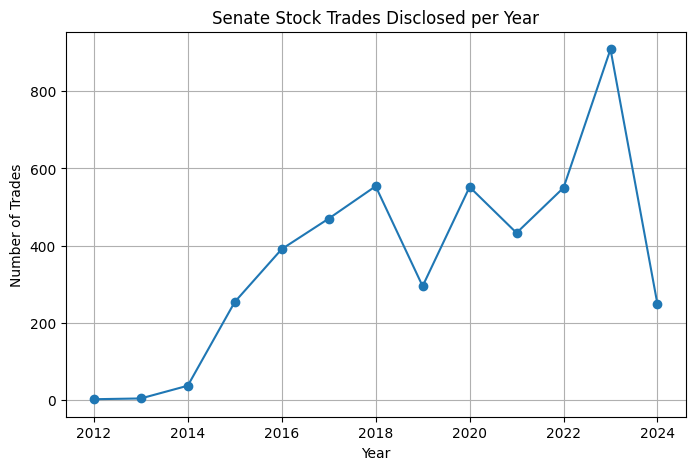

In [11]:
trades_per_year = df["transaction_year"].value_counts().sort_index()

plt.plot(trades_per_year.index, trades_per_year.values, marker="o")
plt.title("Senate Stock Trades Disclosed per Year")
plt.xlabel("Year")
plt.ylabel("Number of Trades")
plt.grid(True)
plt.show()

## Advantages
- Easy to Learn
- Interactive, cloud-based programming — nothing to install
- Strong support for Data Visualization
- Free access to compute (including GPU/TPU)
- Widely used in industry and academia

## Applications in Data Analytics
- Data Cleaning
- Data Transformation
- Data Visualization
- Machine Learning
- Statistical Analysis
- Predictive Analytics (e.g. modelling Senator trading behaviour)

## Precautions
- Save/checkpoint the notebook frequently (File → Save a copy in Drive)
- Use meaningful notebook and variable names
- Restart the runtime when library versions conflict
- Verify library installation before execution
- Re-authenticate with Kaggle if the download step fails after a long idle period

## Viva Questions

**What is Python?**
Python is a high-level programming language used for analytics and AI.

**What is Google Colab?**
A free, cloud-hosted notebook environment for writing and executing Python, built on the Jupyter notebook format.

**What is a Kernel / Runtime?**
The computational engine (here, Colab's cloud runtime) that executes notebook code.

**What is Markdown?**
A lightweight markup language used for formatting text in notebook cells.

**What is NumPy?**
A library used for numerical computing.

**What is Pandas?**
A library used for data manipulation and analysis.

**What is Matplotlib?**
A library used for data visualization.

**What is the shortcut to execute a cell?**
Shift + Enter.

**Why is Colab popular for Data Analytics?**
It supports code, visualization, and documentation in a single, shareable, cloud-hosted environment with no local setup.

**What is the extension of a notebook file?**
`.ipynb`

**What is `kagglehub` used for here?**
To download the Kaggle dataset directly into the Colab runtime without a manual file upload.

## Result
Thus, the Google Colab environment was configured, the US Senate Financial Disclosures (Stocks & Options) dataset was downloaded from Kaggle, and basic Python, NumPy, Pandas, and Matplotlib operations were successfully executed on real data.